In [54]:
import torch
from PIL import Image
import torchvision.transforms as T # transforms: 图像预处理（转换）
import os
from torch.utils.data import Dataset, DataLoader, random_split

## 自定义数据集类

In [55]:
class NoiseImageDataset(Dataset):
    # 初始化
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_names = os.listdir(self.image_dir)

    # 获取数据集长度
    def __len__(self):
        return len(self.image_names)

    # 根据索引号获取元素：(input, target) = (noise_image, image)
    def __getitem__(self, idx):
        # 1. 构建图片的完整访问路径
        image_path = os.path.join(self.image_dir, self.image_names[idx])
        # 2. 打开图片
        image = Image.open(image_path).convert('RGB')
        # 3. 应用转换操作，得到Tensor
        if self.transform is not None:
            img_tensor = self.transform(image)
        else:
            raise ValueError("transform 参数不能为 None!")

        # 4. 加入噪声，得到模型真正输入
        noise_factor = 0.5 # 噪声因子
        img_noise_tensor = img_tensor + torch.randn_like(img_tensor) * noise_factor
        # 将图片数据范围限制在(0, 1)
        img_noise_tensor = torch.clamp(img_noise_tensor, 0, 1) # clamp: 限制张量的值在指定范围内
        return img_noise_tensor, img_tensor # 返回噪声图片和原始图片 (input, target)



In [56]:
# 定义图像转换操作（调整大小，转为Tensor）
transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
])
dataset = NoiseImageDataset(image_dir='../common/dataset', transform=transform)
print(dataset.image_names)

['9733.jpg', '14147.jpg', '63.jpg', '6400.jpg', '24084.jpg', '13628.jpg', '23933.jpg', '12536.jpg', '823.jpg', '15259.jpg', '19463.jpg', '4217.jpg', '16750.jpg', '3578.jpg', '10321.jpg', '16988.jpg', '2666.jpg', '5109.jpg', '11981.jpg', '20584.jpg', '17328.jpg', '10447.jpg', '2100.jpg', '21842.jpg', '11759.jpg', '19305.jpg', '4571.jpg', '16036.jpg', '22393.jpg', '7078.jpg', '12250.jpg', '1409.jpg', '9055.jpg', '14621.jpg', '6366.jpg', '22387.jpg', '12244.jpg', '189.jpg', '23099.jpg', '14635.jpg', '9041.jpg', '6372.jpg', '11995.jpg', '20590.jpg', '10453.jpg', '21856.jpg', '2114.jpg', '4565.jpg', '19311.jpg', '16022.jpg', '4203.jpg', '19477.jpg', '16744.jpg', '10335.jpg', '2672.jpg', '18769.jpg', '14153.jpg', '9727.jpg', '6414.jpg', '77.jpg', '24090.jpg', '23927.jpg', '12522.jpg', '8439.jpg', '837.jpg', '2882.jpg', '3544.jpg', '18999.jpg', '11003.jpg', '17472.jpg', '5135.jpg', '18741.jpg', '13614.jpg', '1353.jpg', '7722.jpg', '15265.jpg', '8411.jpg', '7044.jpg', '15503.jpg', '8377.jpg', 

In [57]:
print(dataset[0])

(tensor([[[0.8272, 0.4483, 0.9843,  ..., 0.5074, 1.0000, 0.8162],
         [1.0000, 1.0000, 0.9495,  ..., 1.0000, 1.0000, 0.6833],
         [0.9886, 1.0000, 1.0000,  ..., 0.0654, 1.0000, 0.6874],
         ...,
         [0.0000, 0.8723, 0.0000,  ..., 0.4907, 1.0000, 1.0000],
         [1.0000, 0.8136, 0.2790,  ..., 1.0000, 0.0147, 0.8087],
         [1.0000, 1.0000, 1.0000,  ..., 0.3099, 1.0000, 1.0000]],

        [[0.9047, 0.4000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [0.7353, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 0.9099, 1.0000,  ..., 1.0000, 1.0000, 0.5902],
         ...,
         [1.0000, 1.0000, 0.3509,  ..., 0.1862, 0.8351, 1.0000],
         [0.5269, 1.0000, 1.0000,  ..., 1.0000, 0.6474, 1.0000],
         [1.0000, 0.4338, 0.7834,  ..., 0.6289, 0.5651, 1.0000]],

        [[0.7369, 1.0000, 0.9813,  ..., 0.9586, 0.7308, 0.2069],
         [0.8856, 0.7760, 0.6353,  ..., 0.2975, 1.0000, 1.0000],
         [1.0000, 0.4754, 0.5128,  ..., 0.0000, 0.9642, 1

In [58]:
print(dataset[0][0].shape) # 噪声图片input的形状
print(dataset[0][1].shape) # 原始图片target的形状

torch.Size([3, 64, 64])
torch.Size([3, 64, 64])


## 划分数据集，构建加载器

In [59]:
# 划分数据集：训练和测试集
train_dataset, test_dataset = random_split(dataset, [0.75, 0.25])
print(len(train_dataset), len(test_dataset))

18640 6213


In [60]:
batch_size = 32

# 构建加载器
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [61]:
for noise_img, target_img in train_loader:
    print(f"noise_img: {noise_img.shape}, target_img: {target_img.shape}")
    break

noise_img: torch.Size([32, 3, 64, 64]), target_img: torch.Size([32, 3, 64, 64])


In [62]:
data_iter = iter(test_loader)
noise_img, target_img = next(data_iter)
print(f"noise_img: {noise_img.shape}, target_img: {target_img.shape}")

noise_img: torch.Size([32, 3, 64, 64]), target_img: torch.Size([32, 3, 64, 64])


## 定义模型

In [63]:
from torch import nn, optim

In [64]:
# 自定义神经网络类: 基于CNN的去噪器
class ConvDenoiser(nn.Module):
    def __init__(self):
        super(ConvDenoiser, self).__init__()
        # 编码器
        # 卷积层
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1, stride=1) # 输出特征形状不变
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, padding=1, stride=1)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1, stride=1)
        # 通用池化层
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        # 解码器
        # 转置卷积层
        self.conv_t1 = nn.ConvTranspose2d(in_channels=8, out_channels=8, kernel_size=3, stride=2, padding=1, output_padding=1) # 输出特征形状为输入的两倍 也可以设置成 kernel_size=2, stride=2, padding=0, output_padding=0, 输出特征同样为输入特征的两倍
        self.conv_t2 = nn.ConvTranspose2d(in_channels=8, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.conv_t3 = nn.ConvTranspose2d(in_channels=16, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1)
        # 输出普通卷积层
        self.conv_out = nn.Conv2d(in_channels=32, out_channels=3, kernel_size=3, padding=1, stride=1)

    # 前向传播
    def forward(self, x):
        # 编码
        x = torch.relu(self.conv1(x))
        x = self.pool(x)

        x = torch.relu(self.conv2(x))
        x = self.pool(x)

        x = torch.relu(self.conv3(x))
        x = self.pool(x)

        # 解码
        x = torch.relu(self.conv_t1(x))

        x = torch.relu(self.conv_t2(x))

        x = torch.relu(self.conv_t3(x))

        # 输出
        y = torch.sigmoid(self.conv_out(x))

        return y

In [65]:
model = ConvDenoiser()
print(model)

ConvDenoiser(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_t1): ConvTranspose2d(8, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (conv_t2): ConvTranspose2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (conv_t3): ConvTranspose2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (conv_out): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


In [66]:
# 前向传播测试
input = torch.randn(10, 3, 64, 64)
output = model(input)
print(output.shape)

torch.Size([10, 3, 64, 64])


## 模型训练

In [67]:
# 超参数
lr = 0.001
epochs = 10

In [68]:
# 定义设备
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

ConvDenoiser(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_t1): ConvTranspose2d(8, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (conv_t2): ConvTranspose2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (conv_t3): ConvTranspose2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (conv_out): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

In [69]:
# 定义损失函数和优化器
loss_fn = nn.MSELoss() # 均方误差损失函数
optimizer = optim.Adam(model.parameters(), lr=lr)

In [70]:
# 训练
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for noise_img, target_img in train_loader:
        noise_img = noise_img.to(device)
        target_img = target_img.to(device)
        # 前向传播，得到输出值
        output = model(noise_img)
        # 计算损失
        loss = loss_fn(output, target_img)
        # 反向传播，计算梯度
        loss.backward()
        # 更新参数
        optimizer.step()
        # 梯度清零
        optimizer.zero_grad()

        total_loss += loss.item()

    # 本轮训练结束，计算平均损失
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")


Epoch [1/10], Loss: 0.0341
Epoch [2/10], Loss: 0.0124
Epoch [3/10], Loss: 0.0113
Epoch [4/10], Loss: 0.0109
Epoch [5/10], Loss: 0.0105
Epoch [6/10], Loss: 0.0103
Epoch [7/10], Loss: 0.0101
Epoch [8/10], Loss: 0.0099
Epoch [9/10], Loss: 0.0098
Epoch [10/10], Loss: 0.0095


## 测试

In [71]:
import matplotlib.pyplot as plt

In [73]:
# 1. 取一个批次的测试图像
data_iter = iter(test_loader)
noise_imgs, target_imgs = next(data_iter)
print(f"noise_imgs: {noise_imgs.shape}, target_imgs: {target_imgs.shape}")

noise_imgs: torch.Size([32, 3, 64, 64]), target_imgs: torch.Size([32, 3, 64, 64])


In [75]:
# 2. 推理预测
with torch.no_grad():
    noise_imgs = noise_imgs.to(device)

    # 前向传播
    outputs = model(noise_imgs)
    print(f"outputs: {outputs.shape}")

outputs: torch.Size([32, 3, 64, 64])


In [76]:
# 3. 转换ndarray 方便画图
images_numpy = target_imgs.permute(0, 2, 3, 1).numpy()
noise_imgs_numpy = noise_imgs.cpu().permute(0, 2, 3, 1).numpy()
denoise_imgs_numpy = outputs.cpu().permute(0, 2, 3, 1).numpy()
print(f"denoise_imgs_numpy: {denoise_imgs_numpy.shape}")

denoise_imgs_numpy: (32, 64, 64, 3)


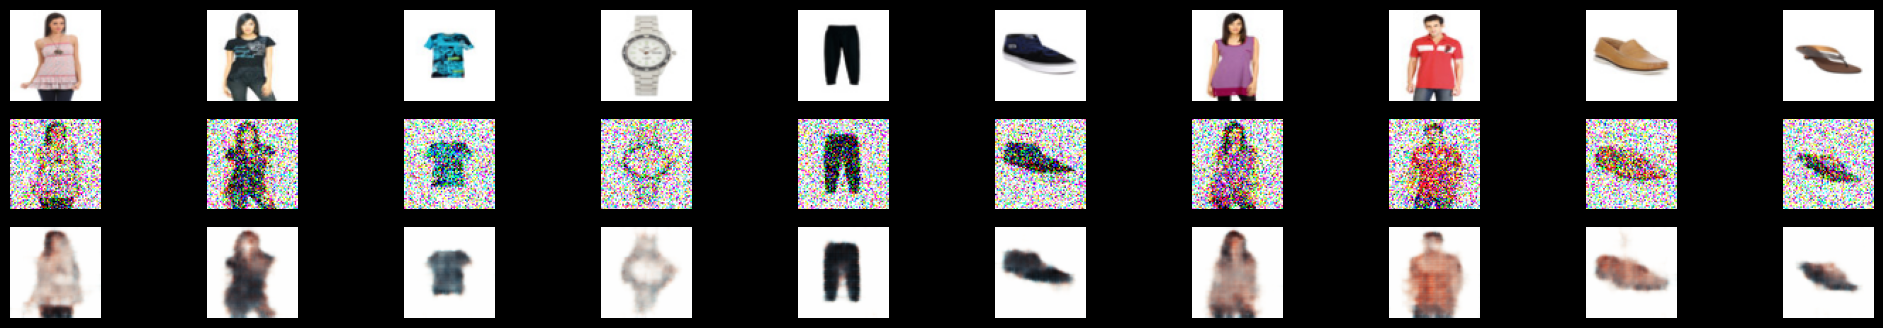

In [77]:
# 4. 画图
fig, axes = plt.subplots(nrows=3, ncols=10, figsize=(25, 4), sharex=True, sharey=True)
for ax_row, imgs in zip(axes, [images_numpy, noise_imgs_numpy, denoise_imgs_numpy]):
    for ax, img in zip(ax_row, imgs):
        ax.imshow(img)
        ax.set_axis_off()
plt.show()